In [9]:
import os
import sys
import glob
import warnings

import numpy    as np

from   PIL      import Image
from   tqdm     import tqdm

warnings.filterwarnings('ignore')

In [10]:
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from   src.analyses         import constraint_analysis
from   src.compute_features import compute_patch_appearance_features
from   src.routines         import flatten_features
from   src.feature_io       import save_features, load_features

In [11]:
features_to_compute = {
    'mean_intensity': True,
    'glcm'          : True,
    'rgb'           : True,
}

metrics_to_compute = {
    'Synth_Violation_%': True,
}

features_to_check = {
    'mean_intensity'  : True,
    'glcm_contrast'   : True,
    'glcm_correlation': True,
    'mean_r'          : True,
    'mean_g'          : True,
    'mean_b'          : True,
}

selected_features = [name for name, enabled in features_to_check.items() if enabled]

In [12]:
real_images_dir                       = input("Path to real images")                   or '../data/real_images'
synth_images_dir                      = input("Path to synth images")                  or '../data/kde_synth_images'
features_dir                          = input("Path for saving or loading features")   or '../data/features'

In [13]:
real_features_file_name               = input("Enter filename for real features")      or 'test_real.npz'
synth_features_file_name              = input("Enter filename for synthetic features") or 'test_synth.npz'

In [14]:
real_patch_appearance_npz_file_path   = os.path.join(features_dir, real_features_file_name)
synth_patch_appearance_npz_file_path  = os.path.join(features_dir, synth_features_file_name)   

real_image_features                   = []
synthetic_image_features              = []

real_image_files                      = glob.glob(os.path.join(real_images_dir,  '*.png'))
synthetic_image_files                 = glob.glob(os.path.join(synth_images_dir, '*.png'))

In [15]:
if os.path.exists(real_patch_appearance_npz_file_path):
    all_real_image_appearance = load_features(real_patch_appearance_npz_file_path)

else:
    print("Processing real patches")
    for img_file in tqdm(real_image_files):
        img   = np.array(Image.open(img_file))
        feats = compute_patch_appearance_features(img, features_to_compute)

        real_image_features.append(feats)

    all_real_image_appearance  = flatten_features(real_image_features)

    save_features(all_real_image_appearance, real_patch_appearance_npz_file_path)

if os.path.exists(synth_patch_appearance_npz_file_path):
    all_synth_image_appearance = load_features(synth_patch_appearance_npz_file_path)

else:
    print("Processing synth patches")
    for img_file in tqdm(synthetic_image_files):
        img   = np.array(Image.open(img_file))
        feats = compute_patch_appearance_features(img, features_to_compute)
        
        synthetic_image_features.append(feats)

    all_synth_image_appearance = flatten_features(synthetic_image_features)

    save_features(all_synth_image_appearance, synth_patch_appearance_npz_file_path)

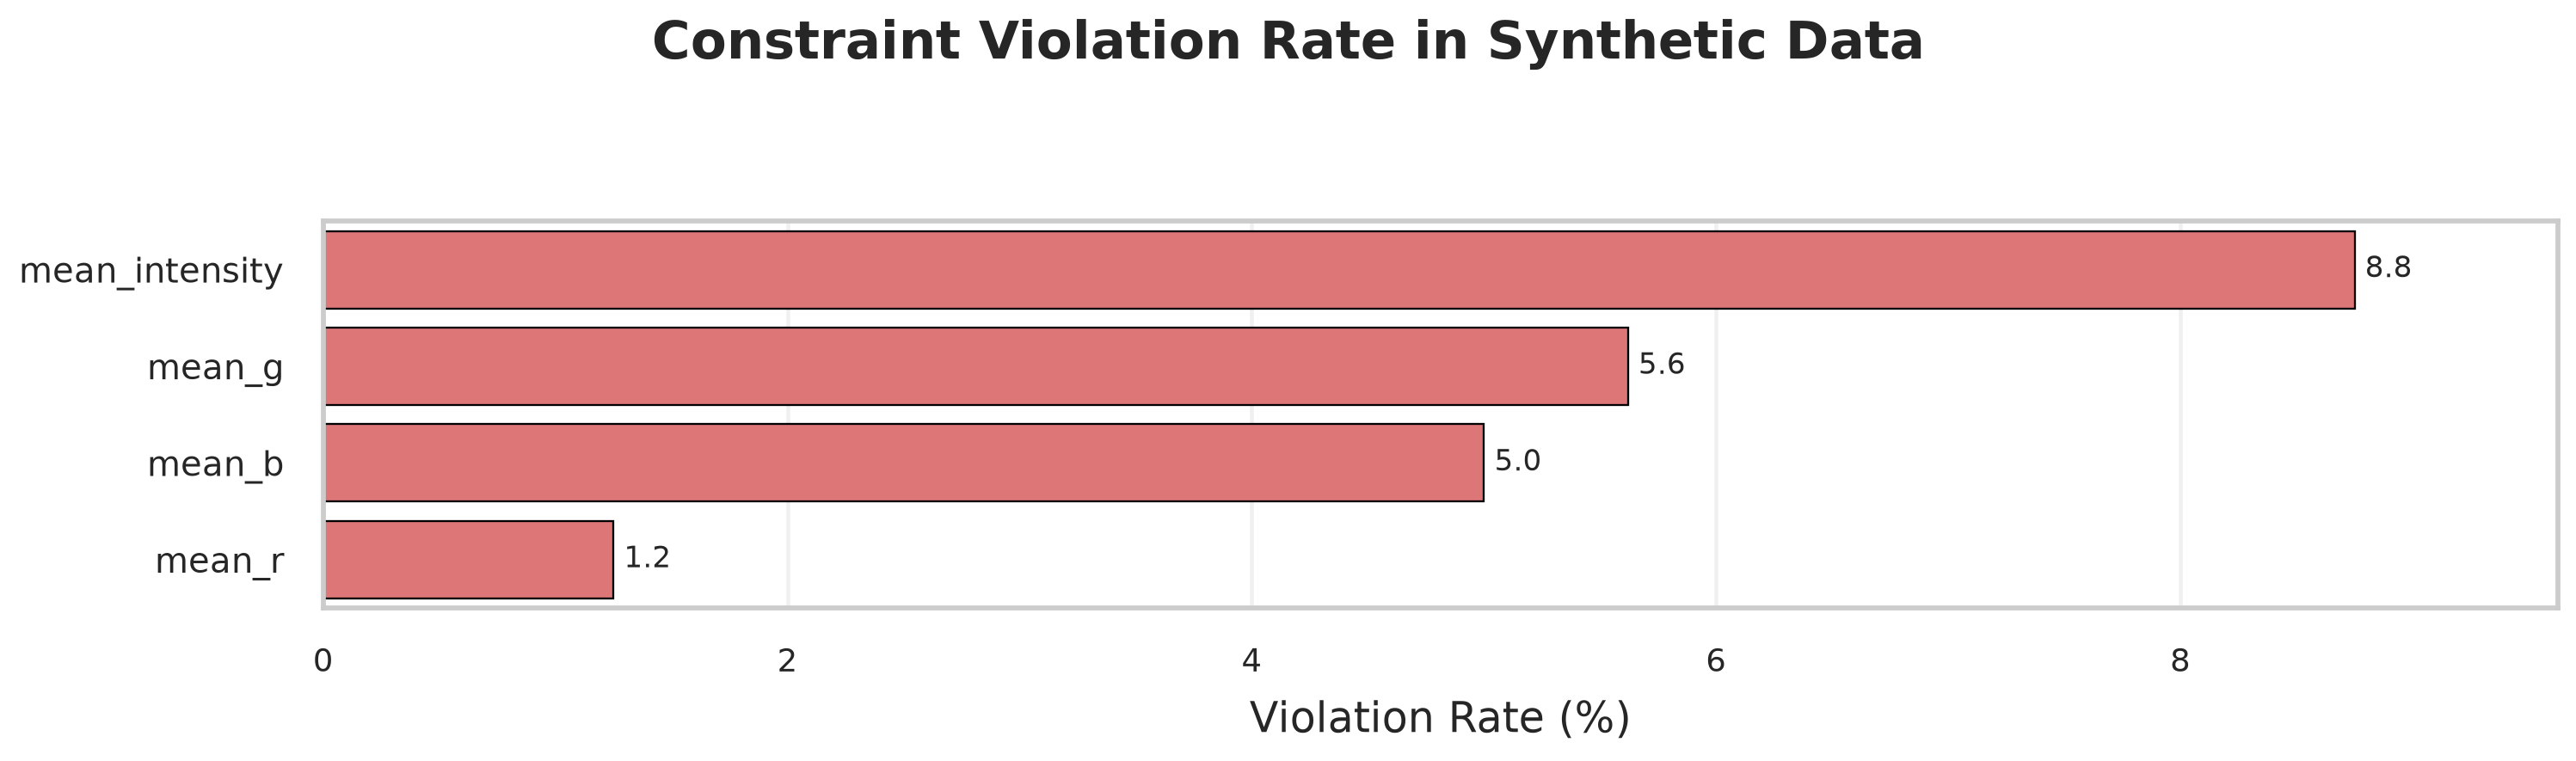

In [16]:
_, constraint_fig = constraint_analysis(
    all_real_image_appearance,
    all_synth_image_appearance,
    features_to_check=selected_features or None,
)

if metrics_to_compute.get('Synth_Violation_%', True) and constraint_fig is not None:
    constraint_fig.show()